In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
# Project root
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [3]:
from src.text_cleaning import (
    is_zero
)

from src.eda_utils import (
    plot_national_allocation,
    plot_enhanced_national_trends,
    national_anomaly_reporting_table,
    commodity_dominance_calculator,
    plot_yearly_national_allocation,
    plot_yearly_state_allocation,
    plot_state_allocation,
    plot_enhanced_state_trends,
    state_anomaly_reporting_table
)

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [5]:
DATA_PATH = "../data/cleaned/"

In [6]:
# LOADING DATA
df_eda = pd.read_csv(DATA_PATH + "primary_data_clean.csv")

In [7]:
df_eda.shape

(67518, 4)

In [8]:
df_eda.dtypes

state_code              object
commodity               object
date                    object
total_allocated_qty    float64
dtype: object

In [9]:
df_eda["date"] = pd.to_datetime(df_eda["date"])

In [10]:
df_eda.dtypes

state_code                     object
commodity                      object
date                   datetime64[ns]
total_allocated_qty           float64
dtype: object

In [11]:
df_eda.columns

Index(['state_code', 'commodity', 'date', 'total_allocated_qty'], dtype='object')

In [12]:
df_eda.isna().sum()

state_code             0
commodity              0
date                   0
total_allocated_qty    0
dtype: int64

In [13]:
df_eda.head()

,state_code,commodity,date,total_allocated_qty
0,TN,rice,2021-10-31,6445.00
1,TN,wheat,2021-10-31,599.00
2,AP,rice,2021-09-30,13030.41
3,AP,rice,2021-09-30,14176.89
4,AP,rice,2021-09-30,16541.31


In [14]:
df_eda.sample(5)

,state_code,commodity,date,total_allocated_qty
46752,MP,wheat,2018-12-31,4644.10
42445,TN,rice,2019-03-31,5471.28
66311,MP,wheat,2017-10-31,7041.41
19477,UP,wheat,2020-06-30,4936.28
50831,AP,rice,2018-09-30,18.49


In [15]:
is_zero(df_eda).sum()

state_code             0
commodity              0
date                   0
total_allocated_qty    0
dtype: int64

In [16]:
df_eda.describe().T

,count,mean,min,25%,50%,75%,max,std
date,67518,2019-09-24 22:08:40.181284608,2017-01-31 00:00:00,2018-10-31 00:00:00,2019-08-31 00:00:00,2020-08-31 00:00:00,2021-10-31 00:00:00,NaN
total_allocated_qty,67518.0,4008.530936,0.01,848.03,2892.605,5581.13,839904.3,10467.773857


In [17]:
# National level Aggregation

national_alloc = (
    df_eda
    .groupby(["date", "commodity"], as_index=False)
    ["total_allocated_qty"]
    .sum()
)

In [18]:
national_alloc = national_alloc.sort_values(["date", "commodity"])
national_alloc.dtypes

date                   datetime64[ns]
commodity                      object
total_allocated_qty           float64
dtype: object

In [19]:
state_alloc = (
    df_eda
    .groupby(["state_code", "date", "commodity"], as_index=False)
    ["total_allocated_qty"]
    .sum()
)

In [20]:
state_alloc = state_alloc.sort_values(
    ["state_code", "date", "commodity"]
)

In [21]:
state_reporting = (
    state_alloc
    .groupby(["date", "commodity"])["state_code"]
    .nunique()
    .reset_index(name="states_reporting")
)

In [22]:
national_alloc = national_alloc.merge(
    state_reporting,
    on=["date", "commodity"],
    how="left"
)

In [23]:
national_alloc.dtypes

date                   datetime64[ns]
commodity                      object
total_allocated_qty           float64
states_reporting                int64
dtype: object

In [24]:
national_alloc.columns

Index(['date', 'commodity', 'total_allocated_qty', 'states_reporting'], dtype='object')

In [25]:
national_alloc.shape

(116, 4)

In [26]:
national_alloc.groupby("date")["commodity"].nunique()
# check if each month has 2 unique commodity values = rice, wheat

date
2017-01-31    2
2017-02-28    2
2017-03-31    2
2017-04-30    2
2017-05-31    2
2017-06-30    2
2017-07-31    2
2017-08-31    2
2017-09-30    2
2017-10-31    2
2017-11-30    2
2017-12-31    2
2018-01-31    2
2018-02-28    2
2018-03-31    2
2018-04-30    2
2018-05-31    2
2018-06-30    2
2018-07-31    2
2018-08-31    2
2018-09-30    2
2018-10-31    2
2018-11-30    2
2018-12-31    2
2019-01-31    2
2019-02-28    2
2019-03-31    2
2019-04-30    2
2019-05-31    2
2019-06-30    2
2019-07-31    2
2019-08-31    2
2019-09-30    2
2019-10-31    2
2019-11-30    2
2019-12-31    2
2020-01-31    2
2020-02-29    2
2020-03-31    2
2020-04-30    2
2020-05-31    2
2020-06-30    2
2020-07-31    2
2020-08-31    2
2020-09-30    2
2020-10-31    2
2020-11-30    2
2020-12-31    2
2021-01-31    2
2021-02-28    2
2021-03-31    2
2021-04-30    2
2021-05-31    2
2021-06-30    2
2021-07-31    2
2021-08-31    2
2021-09-30    2
2021-10-31    2
Name: commodity, dtype: int64

In [27]:
state_alloc.shape
# if 34 states x 72 month x 2 commodities = 5184 rows
# many states and many months must be missing

(2392, 4)

In [28]:
state_alloc.dtypes

state_code                     object
date                   datetime64[ns]
commodity                      object
total_allocated_qty           float64
dtype: object

In [29]:
state_alloc.head(10)

,state_code,date,commodity,total_allocated_qty
0,AN,2017-09-30,rice,0.10
1,AN,2017-10-31,wheat,3.37
2,AN,2017-11-30,rice,1040.43
3,AN,2017-11-30,wheat,22.58
4,AN,2017-12-31,rice,1129.41
5,AN,2017-12-31,wheat,24.05
6,AN,2018-01-31,rice,1220.90
7,AN,2018-01-31,wheat,24.08
8,AN,2018-02-28,rice,116.73
9,AN,2018-03-31,rice,116.19


In [30]:
state_alloc.sample(10)

,state_code,date,commodity,total_allocated_qty
799,HP,2019-12-31,wheat,19379.28
2286,UP,2020-12-31,rice,457346.71
2330,WB,2019-02-28,rice,133995.74
1354,MH,2018-10-31,wheat,346883.06
502,DH,2021-08-31,rice,316.75
1229,KL,2019-09-30,wheat,17563.59
1650,MZ,2020-12-31,rice,3955.61
87,AP,2018-10-31,rice,160158.50
2338,WB,2019-06-30,rice,134290.99
543,DL,2019-03-31,rice,8418.84


In [31]:
national_alloc_pivot = national_alloc.pivot(
    index="date",
    columns="commodity",
    values="total_allocated_qty"
)

In [32]:
national_alloc.columns

Index(['date', 'commodity', 'total_allocated_qty', 'states_reporting'], dtype='object')

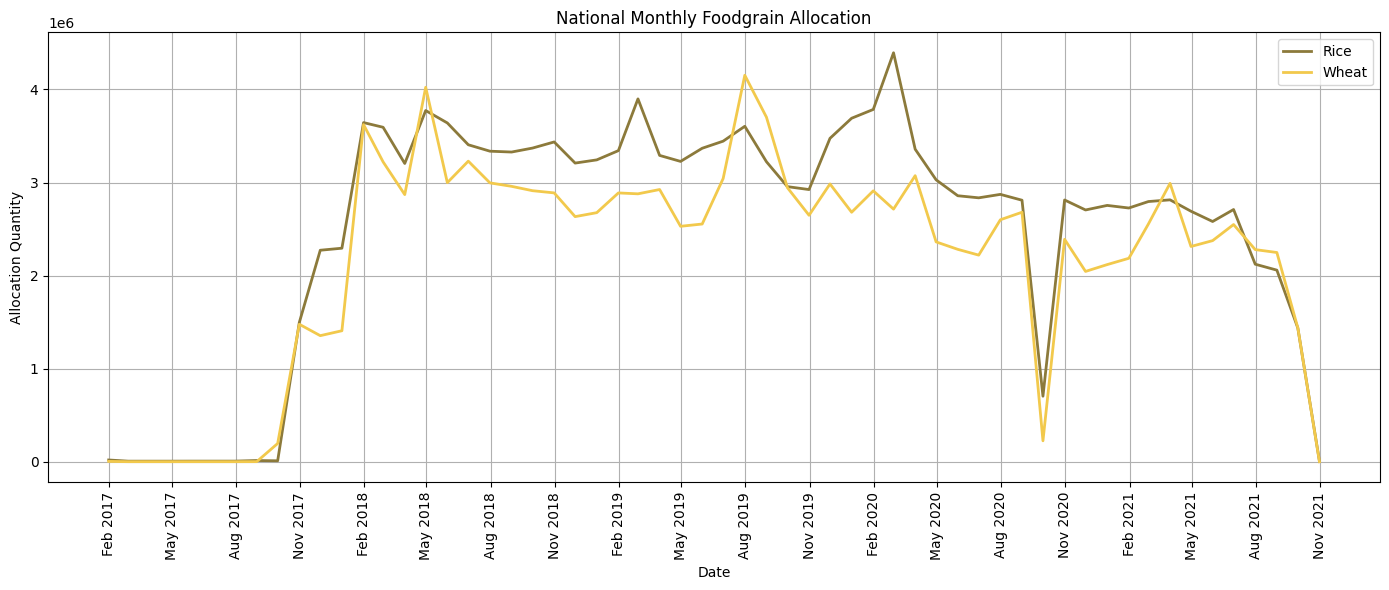

In [33]:
# Plot national allocation 
fig = plot_national_allocation(national_alloc)

## Observation 1
The Data actually starts from Sep 2017. However, it seems, a proper consistent data occurs from Feb 2018 onwards. Similarly, data seems to consistently decrease to zero after Jul 2021. We need to check how many states reported any value at all during these times. 

## Observation 2
Rice seems to be allocated more rather than wheat, consistently . Points to India being a Rice-Dominant country (rather than Wheat Dominant one).

## Observation 3
There is a sharp dip (nearly to zero) for Oct 2020. It could be due to covid-lockdown. (During lockdown, supply to ration-shops might have been disrupted.) We need to check against covid lockdown period in India (25 March 2020 to 1 June 2020).
Or else, the dip reflects temporary under-reporting by one or more large states 

In [34]:
# ------------------------------------
# FURTHER ANALYSIS
# ------------------------------------

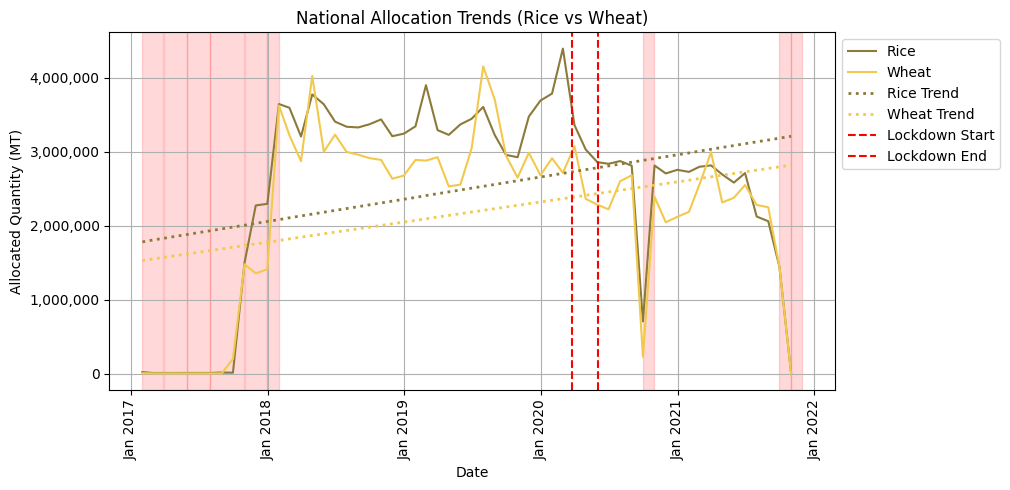

In [35]:
fig, anomaly_dates = plot_enhanced_national_trends(national_alloc)

In [36]:
anomaly_table = national_anomaly_reporting_table(national_alloc)
anomaly_table

,date,states_reporting
0,Jan 2017,2
1,Feb 2017,2
2,Mar 2017,2
3,Apr 2017,2
4,May 2017,2
5,Jun 2017,2
6,Jul 2017,2
7,Aug 2017,12
8,Sep 2017,16
9,Oct 2017,15


## Observation 1 
If we check to see if at least two-thirds of the total number of states are reporting, we can see that in many cases, it is not. Especially in the beginning of the reporting(before 2018), towards the end (last quarter of 2021), and during the drastic dip in the middle(Sep 2020).

## Observation 2 
Checking with the covid lockdown period, the drastic dip is not a result of the Covid Lockdown. It must be under-reporting. You can see in the anomaly reporting table, for Sep 2020 = only 9 states have reproted their data. This is the cause of the sudden dip. It is a reporting issue.

## Hence it is an issue of under-reporting rather than genuine lesser allocation.

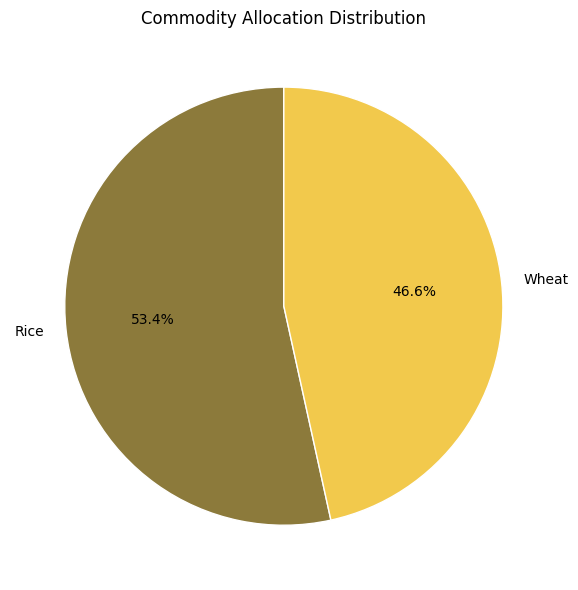

In [37]:
fig, dominant, share = commodity_dominance_calculator(national_alloc)

In [38]:
print(f"Dominant Commodity: {dominant} ({share:.1f}%)")

Dominant Commodity: Rice (53.4%)


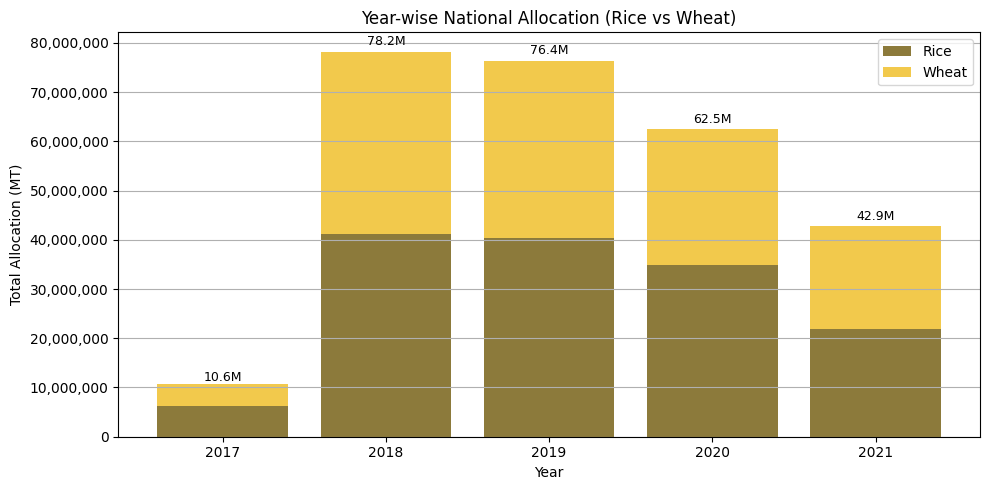

In [39]:
fig = plot_yearly_national_allocation(national_alloc)

## Observation 1
There is heavy under-reporting in 2021. This further corroborates the conclusions drawn from the anomaly window and anomaly reporting table

## Observation 2
There is also under-reporting in 2021, especially during the latter half of the year. Again corroborated from the anomaly window visulaisation and anomaly reporting table.

## Observation 3
There is a significant reduction in allocation during 2020, this could be due to the anomalous month of Sep 2020.

In [40]:
state_alloc.columns

Index(['state_code', 'date', 'commodity', 'total_allocated_qty'], dtype='object')

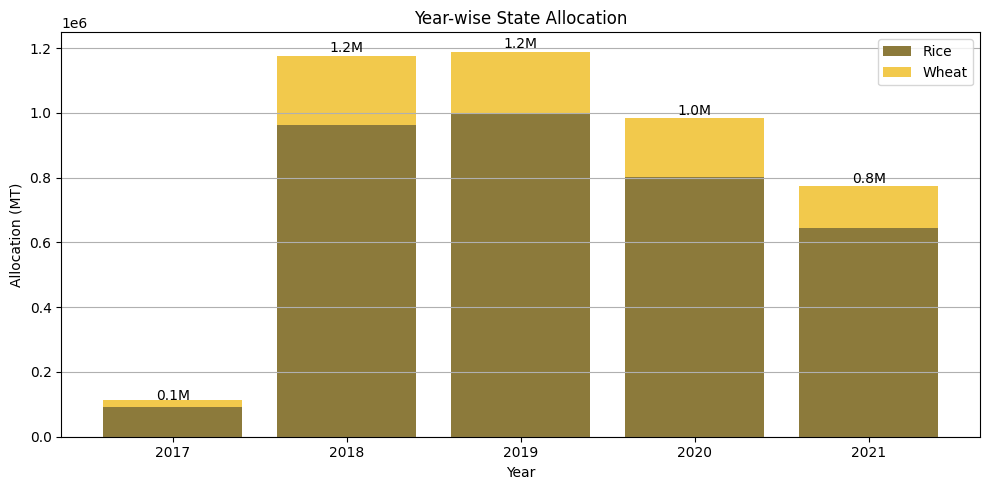

In [41]:
sample_state_code = "KL"
# Filter the data
state_df = state_alloc[state_alloc["state_code"] == sample_state_code].copy()
fig = plot_yearly_state_allocation(state_df)

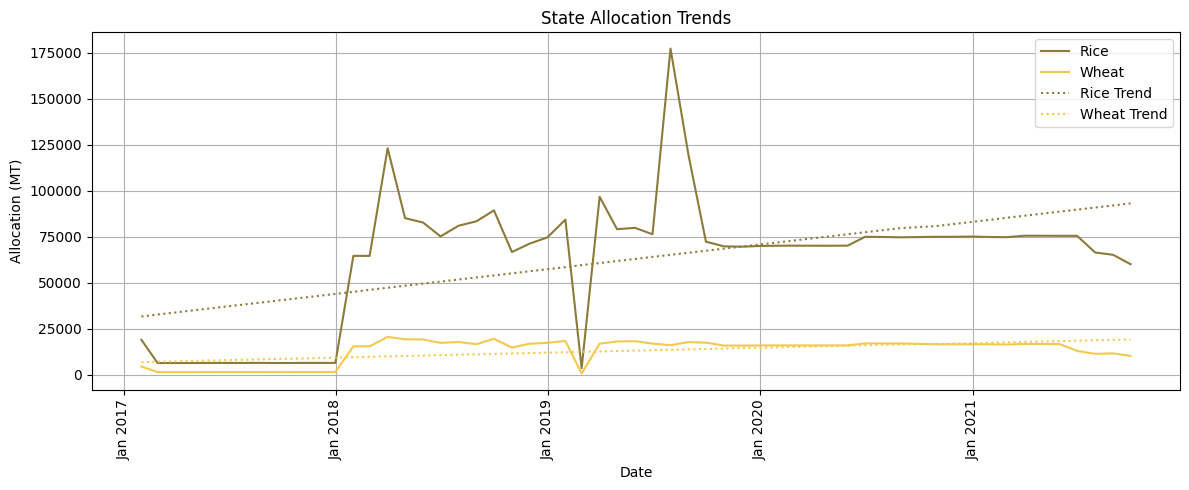

In [42]:
fig = plot_state_allocation(state_df)

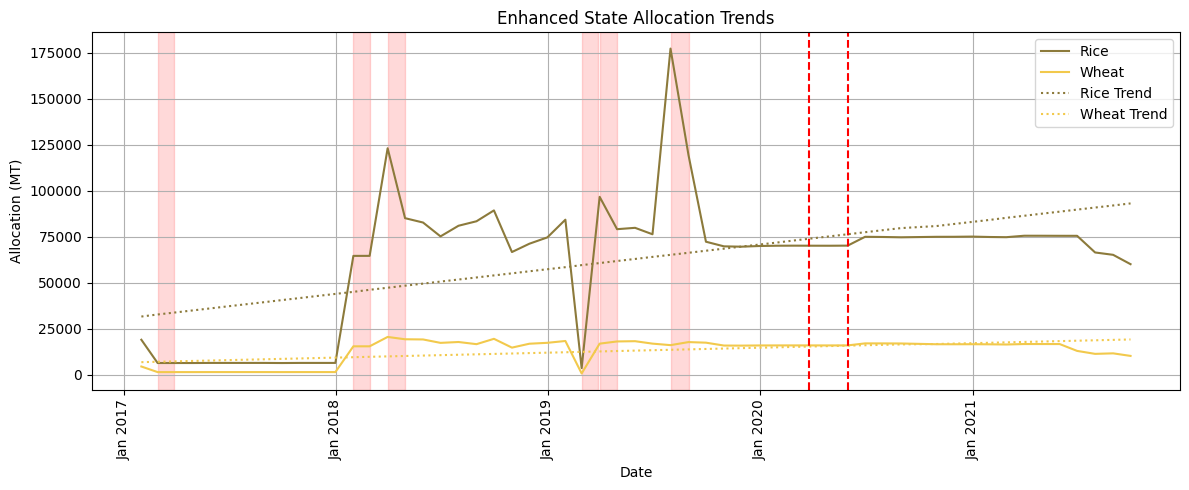

In [43]:
fig, anomaly_dates = plot_enhanced_state_trends(state_df)

In [44]:
anomaly_table_state = state_anomaly_reporting_table(state_df)
anomaly_table_state

,Month,Rice Allocation,Wheat Allocation
0,Feb 2017,6503.33,1565.32
1,Jan 2018,64722.59,15575.91
2,Mar 2018,123229.86,20680.57
3,Feb 2019,3729.51,821.89
4,Mar 2019,96818.37,17035.08
5,Jul 2019,177383.00,16220.28


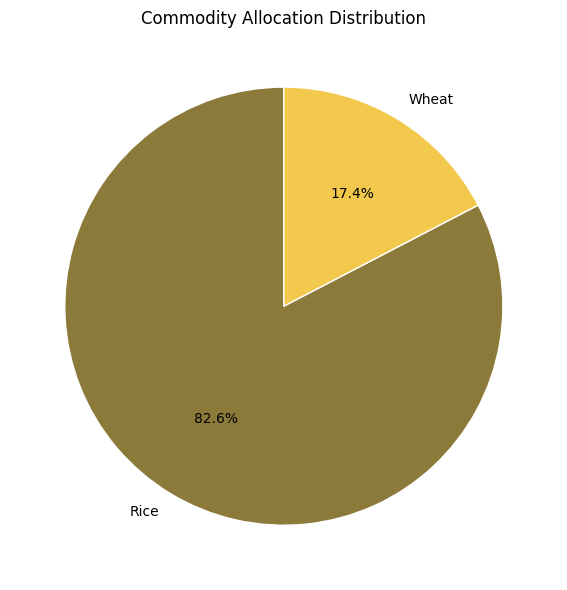

In [45]:
fig, dominant, share = commodity_dominance_calculator(state_df)

In [46]:
print(f"Dominant Commodity: {dominant} ({share:.1f}%)")

Dominant Commodity: Rice (82.6%)


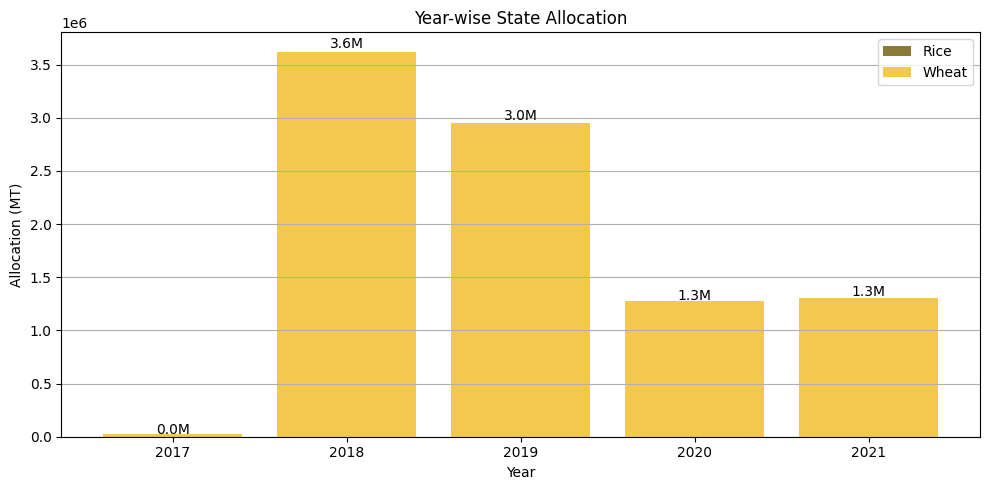

In [47]:
sample_state_code = "PB"
# Filter the data
state_df = state_alloc[state_alloc["state_code"] == sample_state_code].copy()
fig = plot_yearly_state_allocation(state_df)

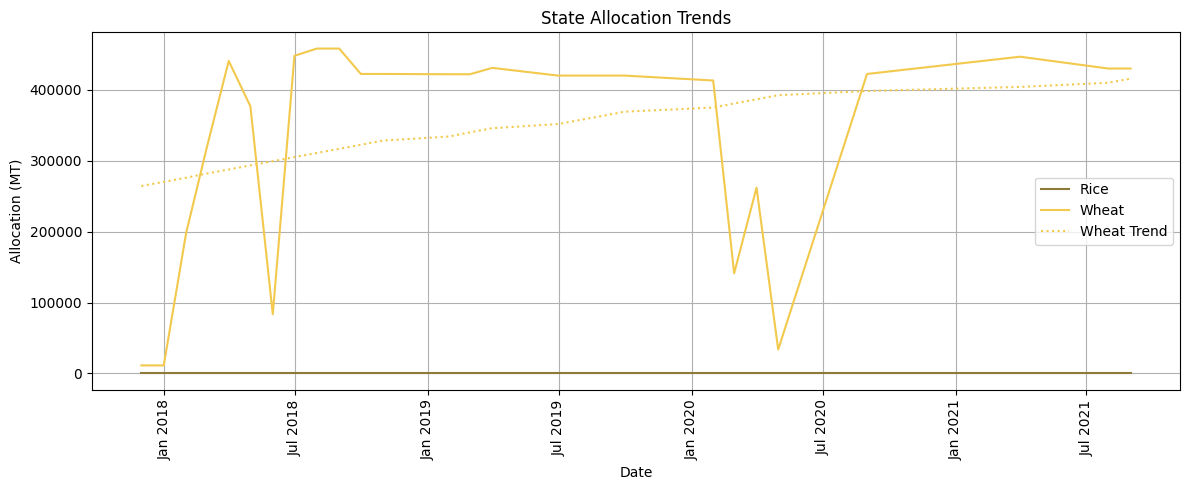

In [48]:
fig = plot_state_allocation(state_df)

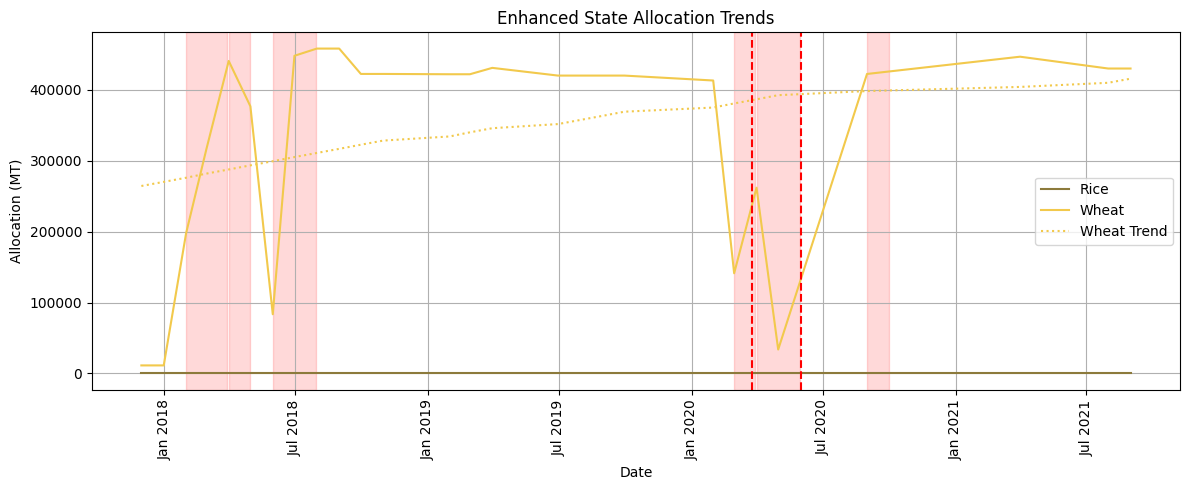

In [49]:
fig, anomaly_dates = plot_enhanced_state_trends(state_df)

In [50]:
anomaly_table_state = state_anomaly_reporting_table(state_df)
anomaly_table_state

,Month,Rice Allocation,Wheat Allocation
0,Jan 2018,0,197825.48
1,Feb 2018,0,315921.80
2,Mar 2018,0,440439.22
3,May 2018,0,83488.17
4,Jun 2018,0,447724.26
5,Feb 2020,0,141196.63
6,Mar 2020,0,261832.04
7,Apr 2020,0,33767.40
8,Aug 2020,0,422102.31


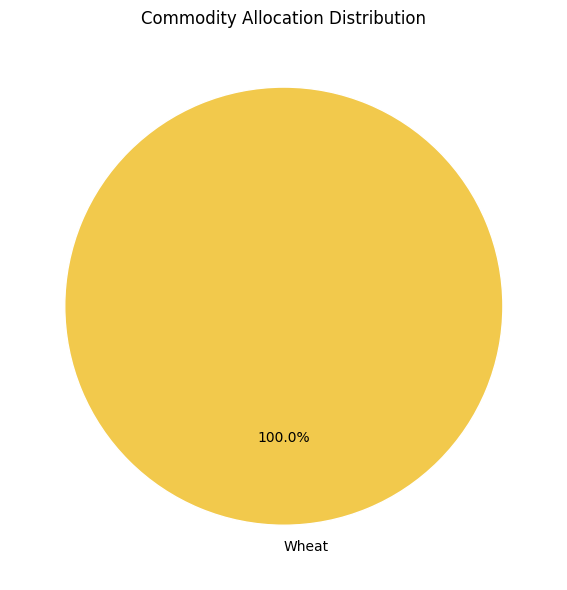

In [51]:
fig, dominant, share = commodity_dominance_calculator(state_df)

In [52]:
print(f"Dominant Commodity: {dominant} ({share:.1f}%)")

Dominant Commodity: Wheat (100.0%)


In [53]:
national_alloc.columns

Index(['date', 'commodity', 'total_allocated_qty', 'states_reporting'], dtype='object')

In [54]:
national_alloc.dtypes

date                   datetime64[ns]
commodity                      object
total_allocated_qty           float64
states_reporting                int64
dtype: object

In [55]:
state_alloc.columns

Index(['state_code', 'date', 'commodity', 'total_allocated_qty'], dtype='object')

In [56]:
state_alloc.dtypes

state_code                     object
date                   datetime64[ns]
commodity                      object
total_allocated_qty           float64
dtype: object

In [57]:
national_alloc.to_csv("../data/cleaned/National_Aggregate_Allocations_Cleaned.csv", index=False)

In [58]:
state_alloc.to_csv("../data/cleaned/State_Level_Allocations_Cleaned.csv", index=False)